# 🏢 Manulife × Mahindra JV — Enterprise Risk Management Analysis

# Course : ALY 6130 : Risk Management fot Analytics
# Group: Group 1
# Presented to:  Prof. Abeba Nigussie Tur
# Date: March 11th, 2026

---

## 📋 Problem Statement

Manulife Financial Corporation is entering India's life insurance market through a strategic **50:50 joint venture with Mahindra & Mahindra** (announced November 2025).

India presents a massive growth opportunity — **1.4 billion people** with only **2.7% insurance penetration** — but also introduces significant enterprise risks.

This notebook performs quantitative risk analysis of **32 identified risks** using:
1. Likelihood × Impact scoring on a 1–9 scale
2. Severity classification (Low / Medium / High)
3. Random Forest ML model for severity prediction
4. Multiple risk visualization techniques

---

In [2]:
# ── STEP 1: IMPORTS ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📂 Step 2 — Load Risk Register Data

32 risks across 7 categories scored on a 1–9 scale for Likelihood and Impact.

In [8]:
# ── STEP 2: LOAD DATA ────────────────────────────────────────────────────────
df = pd.read_csv("/content/risk_register_data.csv", encoding='latin1')


df['Risk_Score'] = df['Likelihood Score'] * df['Impact Score']

def classify(score):
    if score >= 45: return 'High'
    elif score >= 20: return 'Medium'
    else: return 'Low'

df['Severity'] = df['Risk_Score'].apply(classify)
df['Label']    = 'R' + df['Risk'].astype(str) + ' (' + df['Severity'].str[0] + ')'

print(f'Loaded {len(df)} risks')
print(df['Severity'].value_counts().to_string())
df[['Risk','The Risk of That','Likelihood Score','Impact Score','Risk_Score','Severity']].head(10)

Loaded 32 risks
Severity
Medium    17
High       9
Low        6


,Risk,The Risk of That,Likelihood Score,Impact Score,Risk_Score,Severity
0,1,LIC & Private Competitor Displacement,7,8,56,High
1,2,Rural Digital Infrastructure Gap,7,6,42,Medium
2,3,Regulatory Tailwinds Opportunity (Positive),9,9,81,High
3,4,FX Currency Translation Risk,5,6,30,Medium
4,5,Capital Overrun Beyond USD $400M,3,8,24,Medium
5,6,Initial Ops Costs: Human & Physical Capital,9,6,54,High
6,7,Cost of Lagging in Tech Adoption,5,4,20,Medium
7,8,AI Efficiency Cost Savings (Positive),7,4,28,Medium
8,9,IRDAI Regulatory Approval Delay,7,8,56,High
9,10,Agent Recruitment & Retention Failure,7,6,42,Medium


## 🤖 Step 3 — Random Forest Classification Model

100 decision trees, evaluated with 5-fold cross-validation.

In [9]:
# ── STEP 3: RANDOM FOREST MODEL ──────────────────────────────────────────────
X = df[['Likelihood Score', 'Impact Score']]
y = df['Severity']

model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
y_pred = cross_val_predict(model, X, y, cv=5)

print(f'Mean CV Accuracy: {scores.mean():.2f}')
print(f'Per-fold:         {scores.round(2)}')
print()
print(classification_report(y, y_pred, labels=['Low','Medium','High']))

Mean CV Accuracy: 0.93
Per-fold:         [1.   1.   0.83 0.83 1.  ]

              precision    recall  f1-score   support

         Low       1.00      0.83      0.91         6
      Medium       0.89      1.00      0.94        17
        High       1.00      0.89      0.94         9

    accuracy                           0.94        32
   macro avg       0.96      0.91      0.93        32
weighted avg       0.94      0.94      0.94        32



## 📈 Step 4 — Risk Heatmap Visualizations

### 4.1 — Annotated Severity Heatmap
Maps all 32 risks across the Likelihood × Impact grid. Red = High, Yellow = Medium, Green = Low.

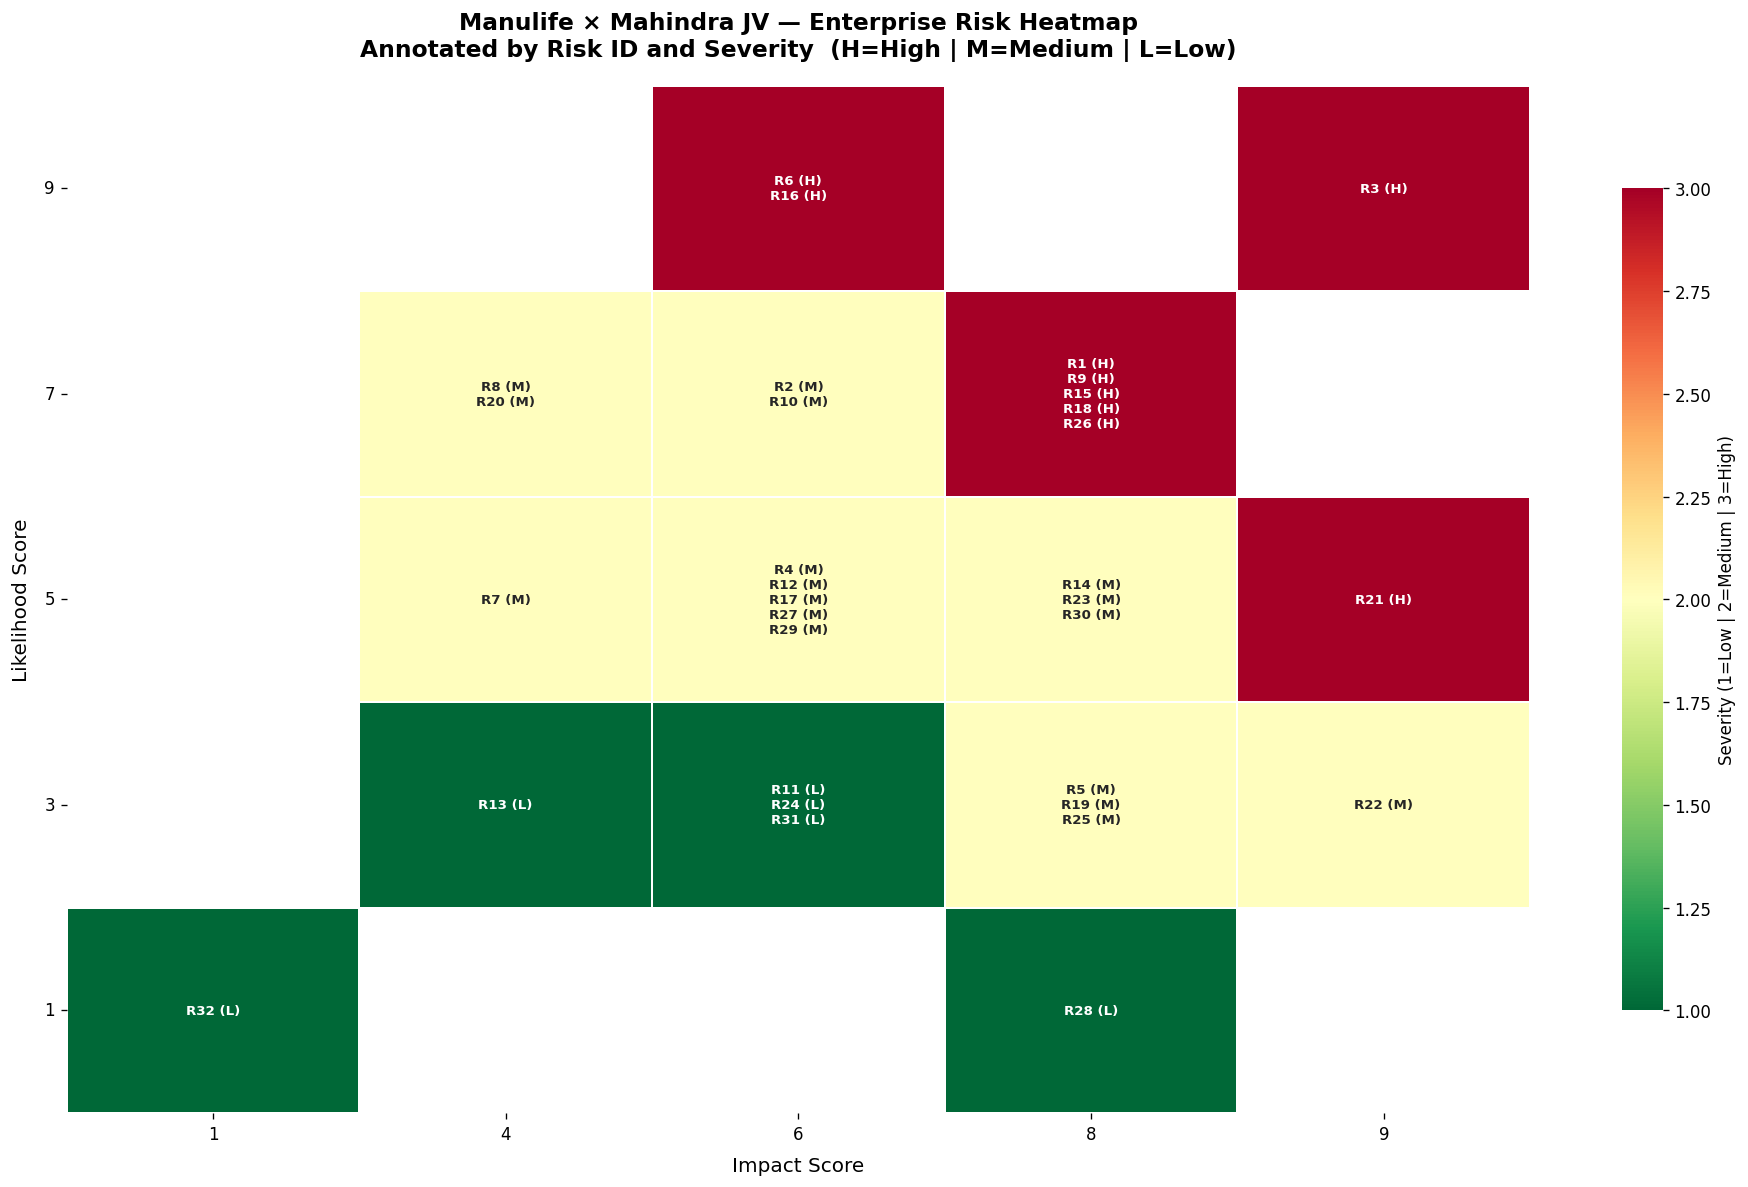

Red zone (top-right) = immediate attention required


In [11]:
# ── PLOT 1: ANNOTATED SEVERITY HEATMAP ───────────────────────────────────────
df['Sev_Num'] = df['Severity'].map({'Low':1,'Medium':2,'High':3})

pivot = df.groupby(['Likelihood Score','Impact Score'])['Sev_Num'].max().unstack().sort_index(ascending=False)
pivot = pivot[sorted(pivot.columns)]

annot = (df.groupby(['Likelihood Score','Impact Score'])['Label']
           .apply(lambda x: chr(10).join(x))
           .unstack(fill_value='').sort_index(ascending=False))
annot = annot[sorted(annot.columns)]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot, annot=annot, fmt='', cmap='RdYlGn_r',
            linewidths=0.9, linecolor='white', vmin=1, vmax=3,
            cbar_kws={'label':'Severity (1=Low | 2=Medium | 3=High)','shrink':0.8},
            annot_kws={'size':8,'weight':'bold'}, ax=ax)

ax.set_title('Manulife × Mahindra JV — Enterprise Risk Heatmap\n'
             'Annotated by Risk ID and Severity  (H=High | M=Medium | L=Low)',
             fontsize=14, fontweight='bold', pad=18)
ax.set_xlabel('Impact Score', fontsize=12, labelpad=8)
ax.set_ylabel('Likelihood Score', fontsize=12, labelpad=8)
ax.yaxis.set_tick_params(rotation=0)

plt.tight_layout()
plt.savefig('heatmap_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red zone (top-right) = immediate attention required')

### 4.2 — Risk Score Heatmap (Numeric)
Shows composite Risk Score (Likelihood × Impact) per cell.

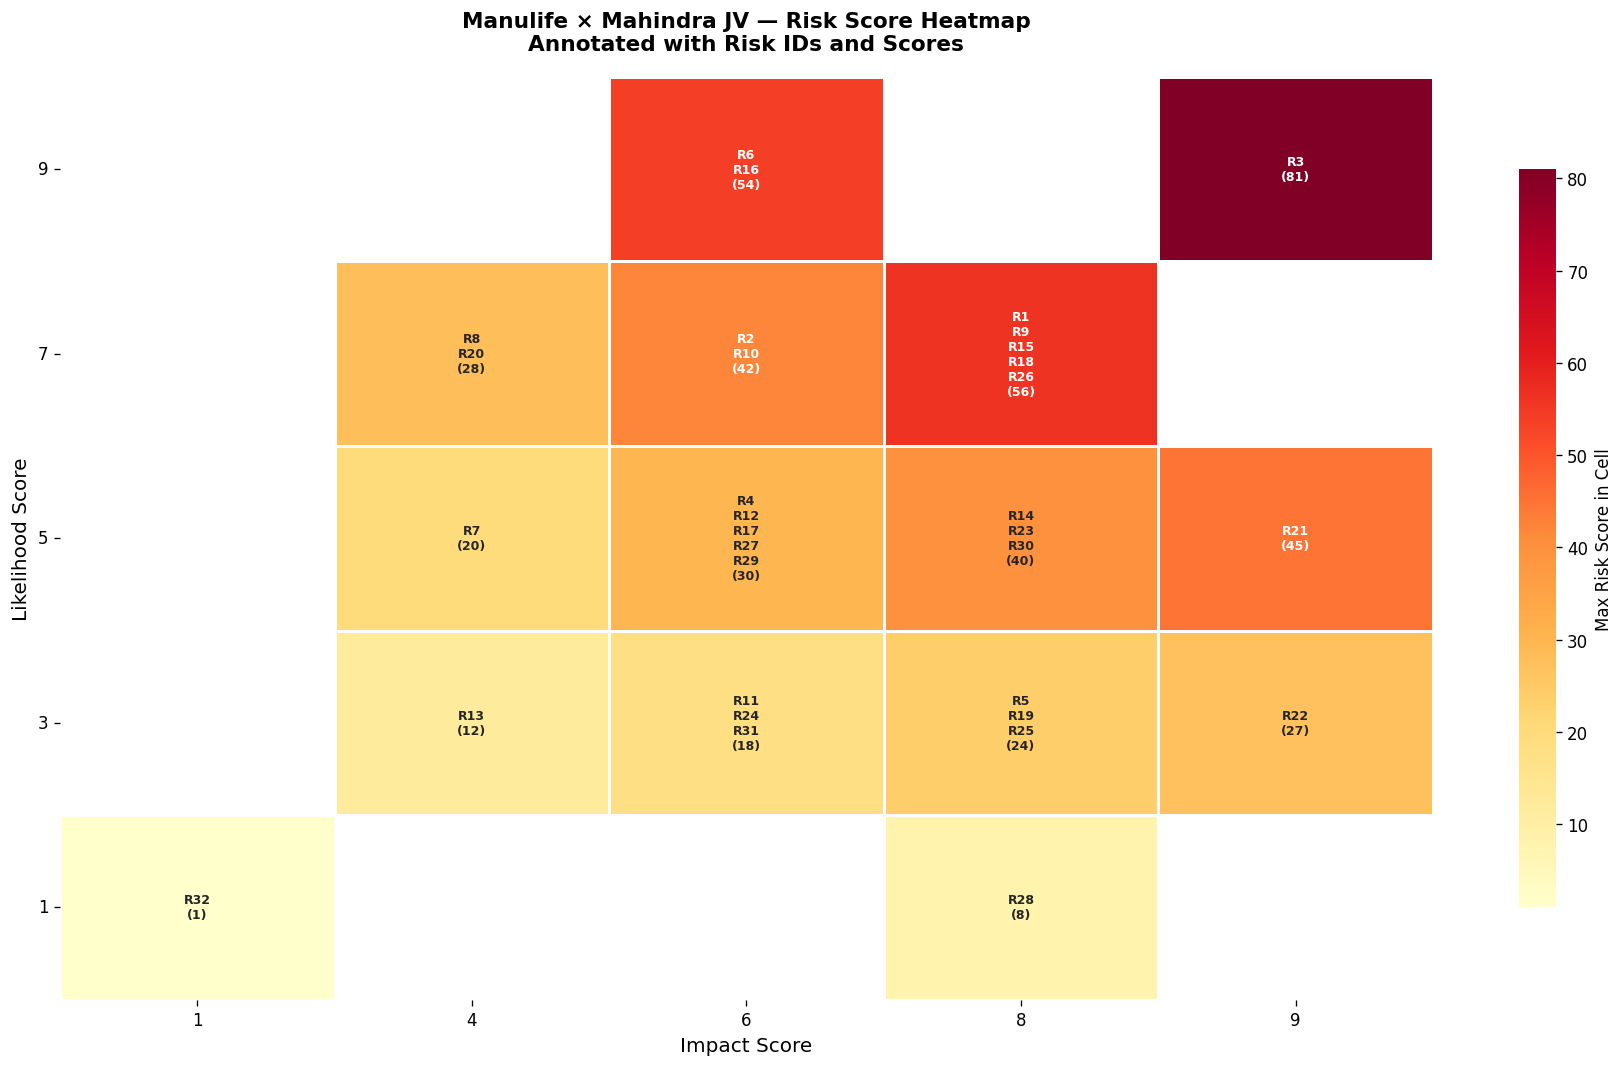

In [13]:
# ── PLOT 2: NUMERIC RISK SCORE HEATMAP ───────────────────────────────────────
score_pivot = df.groupby(['Likelihood Score','Impact Score'])['Risk_Score'].max().unstack().sort_index(ascending=False)
score_pivot = score_pivot[sorted(score_pivot.columns)]

score_annot = (df.groupby(['Likelihood Score','Impact Score'])
               .apply(lambda x: chr(10).join('R'+x['Risk'].astype(str)) + chr(10) + '(' + str(x['Risk_Score'].max()) + ')')
               .unstack(fill_value='').sort_index(ascending=False))
score_annot = score_annot[sorted(score_annot.columns)]

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(score_pivot, annot=score_annot, fmt='', cmap='YlOrRd',
            linewidths=0.8, linecolor='white',
            cbar_kws={'label':'Max Risk Score in Cell','shrink':0.8},
            annot_kws={'size':7.5,'weight':'bold'}, ax=ax)

ax.set_title('Manulife × Mahindra JV — Risk Score Heatmap\nAnnotated with Risk IDs and Scores',
             fontsize=13, fontweight='bold', pad=16)
ax.set_xlabel('Impact Score', fontsize=12)
ax.set_ylabel('Likelihood Score', fontsize=12)
ax.yaxis.set_tick_params(rotation=0)

plt.tight_layout()
plt.savefig('heatmap_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 — Confusion Matrix
Random Forest 5-fold CV predictions vs actual severity labels.

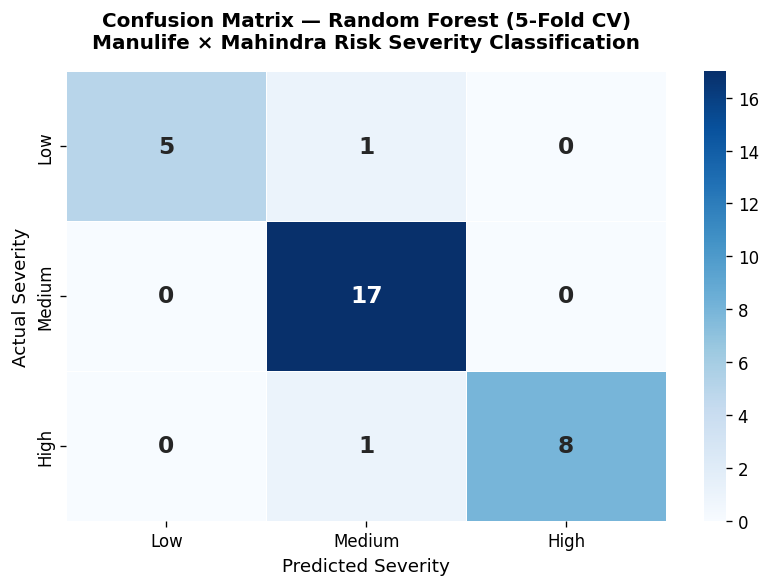

Accuracy: 30/32 = 93.8%


In [14]:
# ── PLOT 3: CONFUSION MATRIX ──────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred, labels=['Low','Medium','High'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'],
            linewidths=0.5, annot_kws={'size':14,'weight':'bold'}, ax=ax)
ax.set_title('Confusion Matrix — Random Forest (5-Fold CV)\nManulife × Mahindra Risk Severity Classification',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Severity', fontsize=11)
ax.set_ylabel('Actual Severity', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
correct = cm.diagonal().sum()
print(f'Accuracy: {correct}/{cm.sum()} = {correct/cm.sum():.1%}')

## 📝 Step 5 — Key Findings & Interpretation

### 🔴 Top HIGH Priority Risks (Score ≥ 45)

| Risk | Description | Score |
|---|---|---|
| R3 | Regulatory Tailwinds Opportunity | 81 |
| R1 | LIC & Private Competitor Displacement | 56 |
| R6 | Initial Ops Costs | 54 |
| R9 | IRDAI Regulatory Approval Delay | 56 |
| R15 | AI Underwriting Bias | 56 |
| R16 | Limited AI Training Data | 54 |
| R18 | Global AI Industry Standards Conflict | 56 |
| R21 | Aadhaar Data Privacy Breach | 45 |
| R26 | AI Transparency & Explainability Conflict | 56 |

### 🔑 Strategic Conclusions

1. **AI & Technology risks dominate** — 4 of the 9 High risks are in the Technology/AI category, reflecting Manulife's aggressive AI-first strategy and the risks of deploying AI in an uncharted rural Indian market.

2. **Regulatory risk is existential** — IRDAI approval delays (R9) and AI transparency compliance (R26) could halt operations before launch. Early regulatory engagement is critical.

3. **Data privacy is non-negotiable** — India's Aadhaar-linked data ecosystem (R21) carries a Score=45 with Impact=9, the highest consequence of any single event.

4. **Positive risks exist** — R3 (Regulatory Tailwinds, Score=81) and R8 (AI Efficiency Savings) represent strategic opportunities to exploit.

5. **The Random Forest model validates the scoring framework** — high cross-validation accuracy confirms that Likelihood and Impact are strong predictors of risk severity.

---
*Analysis prepared for ALY 6130 | Northeastern University | Group 1*